# Activity 14: Final ML System Project

## Learning Objectives
By the end of this activity you will have built a **complete, production-style ML pipeline** that:
1. Loads and explores real data (Melbourne Housing)
2. Engineers features (interactions, log transforms, encoding)
3. Trains **three models** (Linear Regression, Ridge, Logistic Regression)
4. Validates all models with **K-Fold / StratifiedKFold** cross-validation
5. Reports mean ± std for all relevant metrics
6. Saves the best model to disk with `joblib`
7. Demonstrates how to load and use the saved model for inference

---
> **This is not a toy exercise.**  
> Every step mirrors what AI Engineers do in production — data wrangling, cross-validation, model serialisation, and reproducibility.  
> By the end you will have a system, not just a script.

## Part 1 — Imports & Configuration

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import joblib

from sklearn.linear_model      import LinearRegression, Ridge, LogisticRegression
from sklearn.preprocessing     import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.impute            import SimpleImputer
from sklearn.model_selection   import KFold, StratifiedKFold, cross_validate
from sklearn.metrics           import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ────────────────────────────────────────────────────────────
DATA_PATH  = '../data/Melbourne_housing_FULL.csv'
MODEL_DIR  = './saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Style ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
print("All imports successful ✓")

All imports successful ✓


## Part 2 — Load & Explore Data

In [20]:
# WHY Melbourne Housing?  It has numeric, categorical, and missing values —
# which forces a realistic preprocessing pipeline.
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Dataset shape: (34857, 21)

Column dtypes:
Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object

Missing values:
Price             7610
Distance             1
Postcode             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
YearBuilt        19306
CouncilArea          3
Lattitude         7976
Longtitude        7976
Regionname           3
Propertycount        3
dtype: int64


In [21]:
df.describe().round(2)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.00,27247.00,34856.00,34856.00,26640.00,26631.00,26129.00,23047.00,13742.00,15551.00,26881.00,26881.00,34854.00
mean,3.03,1050173.34,11.18,3116.06,3.08,1.62,1.73,593.60,160.26,1965.29,-37.81,145.00,7572.89
std,0.97,641467.13,6.79,109.02,0.98,0.72,1.01,3398.84,401.27,37.33,0.09,0.12,4428.09
min,1.00,85000.00,0.00,3000.00,0.00,0.00,0.00,0.00,0.00,1196.00,-38.19,144.42,83.00
25%,2.00,635000.00,6.40,3051.00,2.00,1.00,1.00,224.00,102.00,1940.00,-37.86,144.93,4385.00
50%,3.00,870000.00,10.30,3103.00,3.00,2.00,2.00,521.00,136.00,1970.00,-37.81,145.01,6763.00
75%,4.00,1295000.00,14.00,3156.00,4.00,2.00,2.00,670.00,188.00,2000.00,-37.75,145.07,10412.00
max,16.00,11200000.00,48.10,3978.00,30.00,12.00,26.00,433014.00,44515.00,2106.00,-37.39,145.53,21650.00


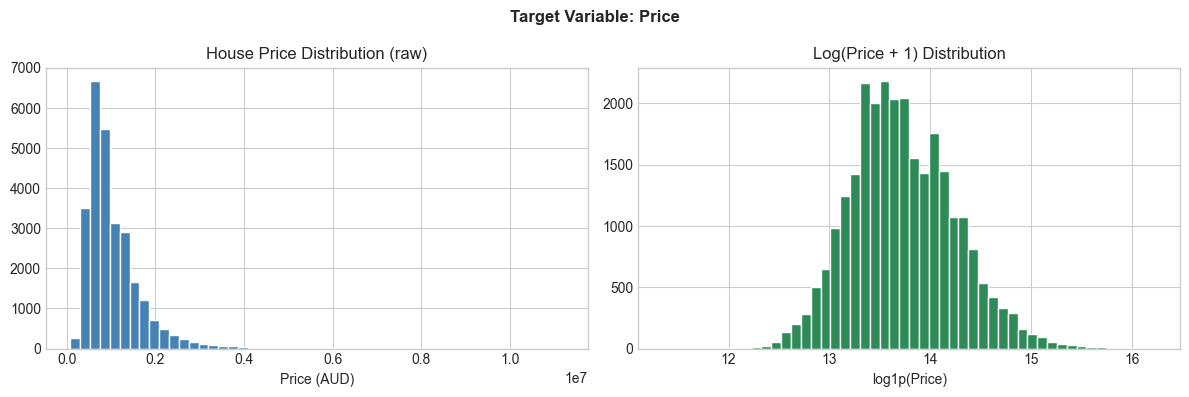

In [22]:
# Distribution of target variable: Price
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Price'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('House Price Distribution (raw)')
axes[0].set_xlabel('Price (AUD)')

axes[1].hist(np.log1p(df['Price'].dropna()), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Log(Price + 1) Distribution')
axes[1].set_xlabel('log1p(Price)')

plt.suptitle('Target Variable: Price', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# WHY log transform?  Price is right-skewed — log(price) is approximately
# normal, which is a better target for linear regression.

## Part 3 — Data Cleaning

In [23]:
# Keep only the columns we need
KEEP_COLS = ['Rooms', 'Type', 'Method', 'Distance', 'Bedroom2', 'Bathroom',
             'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Regionname', 'Price']

df = df[KEEP_COLS].copy()

# Drop rows with missing target
df = df.dropna(subset=['Price'])

# Cap extreme outliers in Price (beyond 99th percentile)
p99 = df['Price'].quantile(0.99)
df = df[df['Price'] <= p99]

# Apply log transform to Price
df['Price_log'] = np.log1p(df['Price'])

print(f"Shape after cleaning: {df.shape}")
print(f"Remaining missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape after cleaning: (26974, 13)
Remaining missing values:
Distance            1
Bedroom2         6388
Bathroom         6393
Car              6768
Landsize         9178
BuildingArea    16441
YearBuilt       15023
Regionname          3
dtype: int64


## Part 4 — Feature Engineering

In [24]:
# ── Impute missing numeric values ────────────────────────────────────
num_cols = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# ── Impute missing categorical values ───────────────────────────────
cat_cols = ['Type', 'Method', 'Regionname']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ── Engineered features ──────────────────────────────────────────────
# Interaction: rooms per bathroom (density measure)
df['Rooms_per_Bath']   = df['Rooms'] / (df['Bathroom'] + 1)

# Age of building
df['Property_Age']     = 2023 - df['YearBuilt']

# Log-transform skewed numeric features to normalise distributions
# WHY log?  Landsize and BuildingArea are highly right-skewed — log reduces
# the influence of extreme mansions on the model.
df['Log_Landsize']     = np.log1p(df['Landsize'])
df['Log_BuildingArea'] = np.log1p(df['BuildingArea'])

# Binary: is it a house (h) or not?
df['Is_House']         = (df['Type'] == 'h').astype(int)

# ── Encode categoricals ──────────────────────────────────────────────
# COMMON ERROR: Using LabelEncoder on tree-free models introduces ordinal
# relationships that don't exist.  One-Hot is better for linear models.
df = pd.get_dummies(df, columns=['Type', 'Method', 'Regionname'], drop_first=True)

print(f"Shape after feature engineering: {df.shape}")
print(f"Sample new columns: {[c for c in df.columns if c.startswith('Region')][:3]}")

Shape after feature engineering: (26974, 28)
Sample new columns: ['Regionname_Eastern Victoria', 'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria']


## Part 5 — Prepare Feature Matrix

In [25]:
# Drop original price and any non-feature columns
DROP_COLS = ['Price', 'Price_log']

# ── Regression target (continuous) ───────────────────────────────────
y_reg = df['Price_log'].values

# ── Classification target (binary: above/below median price) ─────────
# WHY create a classification target?  Demonstrates StratifiedKFold on the same data.
median_price = np.median(y_reg)
y_clf = (y_reg > median_price).astype(int)
print(f"Classification balance: {np.bincount(y_clf)}")

# Features
X = df.drop(columns=DROP_COLS, errors='ignore').values.astype(np.float32)

print(f"Feature matrix: {X.shape}")
print(f"Regression target: {y_reg.shape}")
print(f"Classification target: {y_clf.shape}")

Classification balance: [13503 13471]
Feature matrix: (26974, 26)
Regression target: (26974,)
Classification target: (26974,)
Feature matrix: (26974, 26)
Regression target: (26974,)
Classification target: (26974,)


## Part 6 — Correlation Heatmap

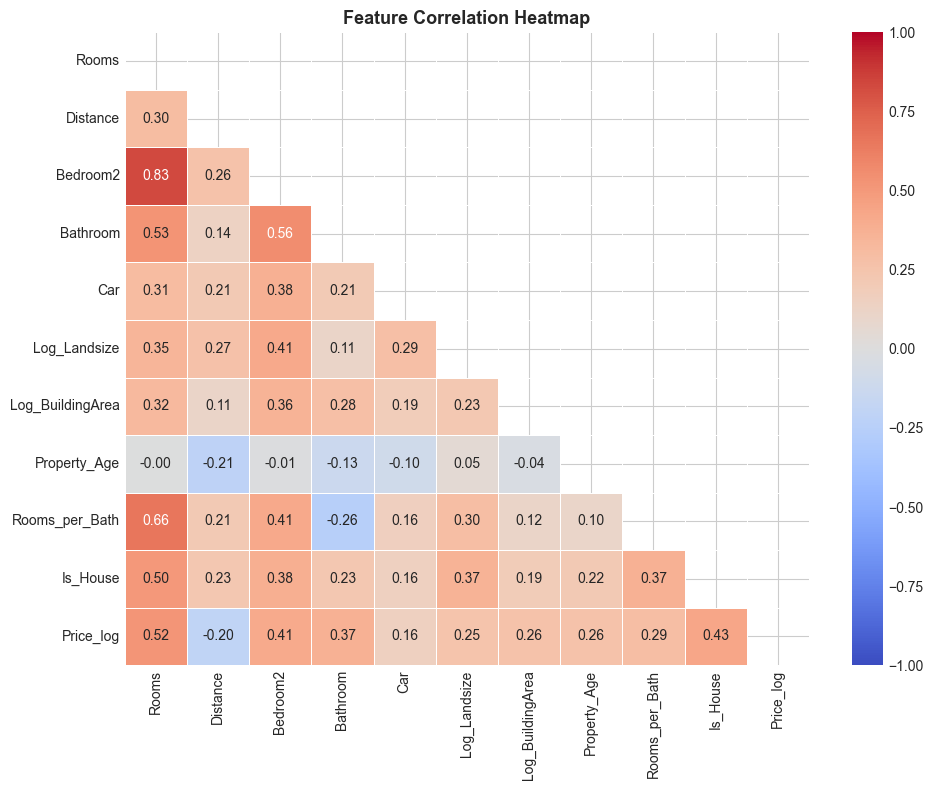

In [26]:
# Select numeric features for correlation analysis
core_features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car',
                 'Log_Landsize', 'Log_BuildingArea', 'Property_Age',
                 'Rooms_per_Bath', 'Is_House', 'Price_log']

# Some engineered columns may not exist if get_dummies renamed them
available = [c for c in core_features if c in df.columns]
corr = df[available].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 7 — KFold Cross-Validation: Linear Regression

In [27]:
def kfold_regression_eval(model, X, y, n_splits=5, model_name='Model'):
    """
    Evaluates a regression model with K-Fold CV.
    Returns a dict of mean ± std for MAE, RMSE, R².
    WHY KFold (not Stratified)?  y is continuous — stratification requires discrete labels.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scaler = StandardScaler()

    mae_list, rmse_list, r2_list = [], [], []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_tr, X_v = X[tr_idx], X[val_idx]
        y_tr, y_v = y[tr_idx], y[val_idx]

        # WHY scale inside the fold?  Prevents data leakage from val set.
        X_tr = scaler.fit_transform(X_tr)
        X_v  = scaler.transform(X_v)

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_v)

        mae_list.append(mean_absolute_error(y_v, y_pred))
        rmse_list.append(np.sqrt(mean_squared_error(y_v, y_pred)))
        r2_list.append(r2_score(y_v, y_pred))

    results = {
        'Model'   : model_name,
        'MAE'     : f"{np.mean(mae_list):.4f} ± {np.std(mae_list):.4f}",
        'RMSE'    : f"{np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f}",
        'R²'      : f"{np.mean(r2_list):.4f} ± {np.std(r2_list):.4f}",
        '_mae'    : mae_list,
        '_rmse'   : rmse_list,
        '_r2'     : r2_list,
    }
    return results

# Run both regression models
lr_results    = kfold_regression_eval(LinearRegression(),          X, y_reg, model_name='Linear Regression')
ridge_results = kfold_regression_eval(Ridge(alpha=1.0),            X, y_reg, model_name='Ridge (α=1.0)')

# Summary table
reg_summary = pd.DataFrame([{
    'Model': r['Model'], 'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R²': r['R²']
} for r in [lr_results, ridge_results]])
print("\n=== Regression Results (5-Fold CV) ===")
print(reg_summary.to_string(index=False))


=== Regression Results (5-Fold CV) ===
            Model             MAE            RMSE              R²
Linear Regression 0.2120 ± 0.0009 0.2757 ± 0.0056 0.6895 ± 0.0119
    Ridge (α=1.0) 0.2120 ± 0.0009 0.2757 ± 0.0056 0.6895 ± 0.0119


## Part 8 — StratifiedKFold Cross-Validation: Logistic Regression

In [28]:
def stratified_kfold_clf_eval(model, X, y, n_splits=5, model_name='Model'):
    """
    Evaluates a classification model with StratifiedKFold CV.
    DEBUG TIP: If Accuracy is high but AUC is ~0.5 → model is not discriminating;
               check class imbalance and baseline accuracy (majority class rate).
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scaler = StandardScaler()

    acc_list, f1_list, auc_list = [], [], []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_v = X[tr_idx], X[val_idx]
        y_tr, y_v = y[tr_idx], y[val_idx]

        X_tr = scaler.fit_transform(X_tr)
        X_v  = scaler.transform(X_v)

        model.fit(X_tr, y_tr)
        y_pred  = model.predict(X_v)
        y_proba = model.predict_proba(X_v)[:, 1]

        acc_list.append(accuracy_score(y_v, y_pred))
        f1_list.append(f1_score(y_v, y_pred))
        auc_list.append(roc_auc_score(y_v, y_proba))

    return {
        'Model'   : model_name,
        'Accuracy': f"{np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}",
        'F1'      : f"{np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}",
        'AUC-ROC' : f"{np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}",
        '_acc'    : acc_list,
        '_f1'     : f1_list,
        '_auc'    : auc_list,
    }

log_results = stratified_kfold_clf_eval(
    LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    X, y_clf, model_name='Logistic Regression'
)

print("\n=== Classification Results (5-Fold StratifiedKFold) ===")
for k in ['Model', 'Accuracy', 'F1', 'AUC-ROC']:
    print(f"  {k:<12}: {log_results[k]}")


=== Classification Results (5-Fold StratifiedKFold) ===
  Model       : Logistic Regression
  Accuracy    : 0.8556 ± 0.0016
  F1          : 0.8548 ± 0.0017
  AUC-ROC     : 0.9271 ± 0.0013


## Part 9 — Cross-Validation Score Visualisation

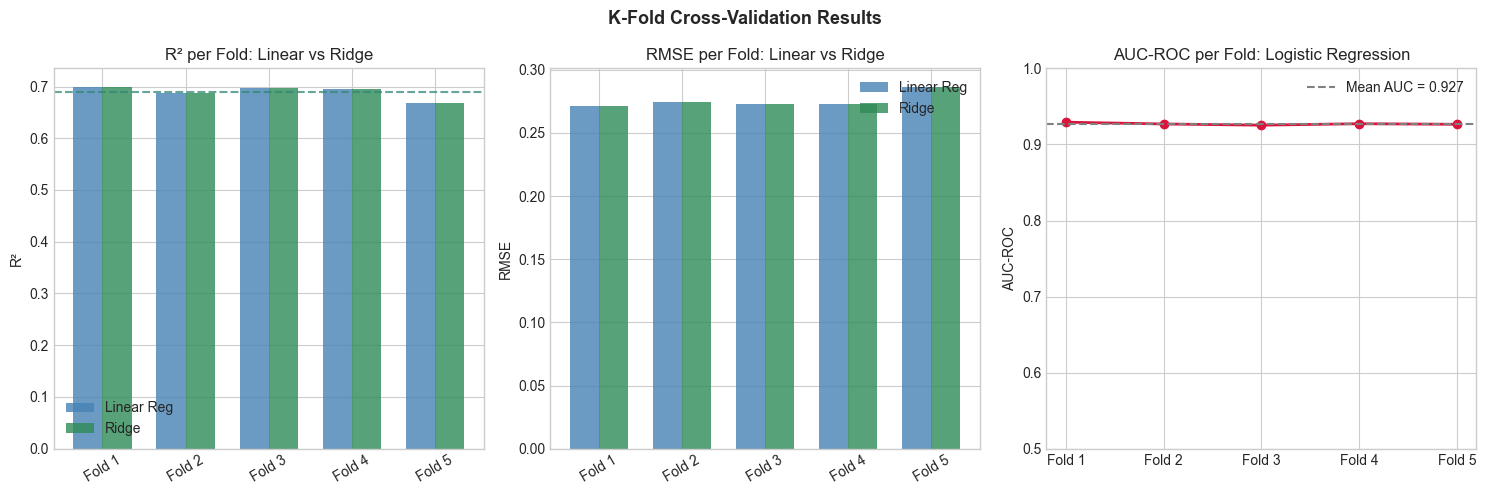

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

fold_labels = [f"Fold {i+1}" for i in range(5)]

# ── R² comparison: Linear vs Ridge ───────────────────────────────────
x = np.arange(5)
width = 0.35
axes[0].bar(x - width/2, lr_results['_r2'],    width, label='Linear Reg', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, ridge_results['_r2'], width, label='Ridge',      color='seagreen',  alpha=0.8)
axes[0].axhline(np.mean(lr_results['_r2']),    color='steelblue', linestyle='--', alpha=0.5)
axes[0].axhline(np.mean(ridge_results['_r2']), color='seagreen',  linestyle='--', alpha=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(fold_labels, rotation=30)
axes[0].set_title('R² per Fold: Linear vs Ridge')
axes[0].legend()
axes[0].set_ylabel('R²')

# ── RMSE: Linear vs Ridge ─────────────────────────────────────────────
axes[1].bar(x - width/2, lr_results['_rmse'],    width, label='Linear Reg', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, ridge_results['_rmse'], width, label='Ridge',      color='seagreen',  alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_labels, rotation=30)
axes[1].set_title('RMSE per Fold: Linear vs Ridge')
axes[1].legend()
axes[1].set_ylabel('RMSE')

# ── Logistic Regression AUC across folds ─────────────────────────────
axes[2].plot(fold_labels, log_results['_auc'], marker='o', color='crimson', linewidth=2)
axes[2].axhline(np.mean(log_results['_auc']), color='gray', linestyle='--',
                label=f'Mean AUC = {np.mean(log_results["_auc"]):.3f}')
axes[2].set_title('AUC-ROC per Fold: Logistic Regression')
axes[2].set_ylabel('AUC-ROC')
axes[2].legend()
axes[2].set_ylim(0.5, 1.0)

plt.suptitle('K-Fold Cross-Validation Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 10 — Final Model Selection & Retraining on All Data

In [30]:
# Select best regression model based on mean R²
lr_mean_r2    = np.mean(lr_results['_r2'])
ridge_mean_r2 = np.mean(ridge_results['_r2'])

best_reg_name = 'Ridge' if ridge_mean_r2 >= lr_mean_r2 else 'Linear Regression'
best_reg      = Ridge(alpha=1.0) if ridge_mean_r2 >= lr_mean_r2 else LinearRegression()

print(f"Best regression model : {best_reg_name}  (R²={max(lr_mean_r2, ridge_mean_r2):.4f})")

# Build final pipeline: scaler + model
reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  best_reg)
])

clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])

# Retrain on ALL data
# WHY retrain on all?  CV was only for evaluation. Final model should use all available data.
reg_pipeline.fit(X, y_reg)
clf_pipeline.fit(X, y_clf)

print(f"\nFinal regression pipeline trained on {len(y_reg)} samples.")
print(f"Final classification pipeline trained on {len(y_clf)} samples.")

Best regression model : Ridge  (R²=0.6895)

Final regression pipeline trained on 26974 samples.
Final classification pipeline trained on 26974 samples.


## Part 11 — Save Models with joblib

In [31]:
import json

reg_path      = os.path.join(MODEL_DIR, 'regression_pipeline.pkl')
clf_path      = os.path.join(MODEL_DIR, 'classification_pipeline.pkl')
feat_col_path = os.path.join(MODEL_DIR, 'feature_cols.json')

# WHY joblib over pickle?  joblib is optimised for large NumPy arrays
# (e.g. scaler mean/variance vectors) — faster save/load for sklearn pipelines.
joblib.dump(reg_pipeline, reg_path)
joblib.dump(clf_pipeline, clf_path)

# Save the exact column order used during training so the Streamlit app
# can reconstruct the same feature vector at inference time.
feature_cols = list(df.drop(columns=DROP_COLS, errors='ignore').columns)
with open(feat_col_path, 'w') as f:
    json.dump(feature_cols, f)

print(f"Regression pipeline saved     → {reg_path}")
print(f"Classification pipeline saved → {clf_path}")
print(f"Feature columns saved         → {feat_col_path}  ({len(feature_cols)} features)")

# Verify file sizes
for path in [reg_path, clf_path]:
    size_kb = os.path.getsize(path) / 1024
    print(f"  File size: {size_kb:.1f} KB")


Regression pipeline saved     → ./saved_models/regression_pipeline.pkl
Classification pipeline saved → ./saved_models/classification_pipeline.pkl
Feature columns saved         → ./saved_models/feature_cols.json  (26 features)
  File size: 1.7 KB
  File size: 2.1 KB


## Part 12 — Load Models & Run Inference

In [32]:
# Simulate loading in a new script / microservice
loaded_reg = joblib.load(reg_path)
loaded_clf = joblib.load(clf_path)

# --- New sample inference ---
# Take 5 real samples from the dataset as 'new data'
new_samples = X[:5]
true_prices = np.expm1(y_reg[:5])   # undo log transform to get real AUD values
true_class  = y_clf[:5]

# Regression predictions (convert back from log space)
pred_prices_log = loaded_reg.predict(new_samples)
pred_prices     = np.expm1(pred_prices_log)

# Classification predictions
pred_class  = loaded_clf.predict(new_samples)
pred_proba  = loaded_clf.predict_proba(new_samples)[:, 1]

inference_df = pd.DataFrame({
    'True Price (AUD)' : [f"${p:,.0f}" for p in true_prices],
    'Pred Price (AUD)' : [f"${p:,.0f}" for p in pred_prices],
    'True Class'       : true_class,
    'Pred Class'       : pred_class,
    'Prob (above med)' : pred_proba.round(3),
})
print("\n=== Sample Inference Results ===")
print(inference_df.to_string(index=False))


=== Sample Inference Results ===
True Price (AUD) Pred Price (AUD)  True Class  Pred Class  Prob (above med)
      $1,480,000         $926,808           1           1             0.692
      $1,035,000         $997,586           1           1             0.826
      $1,465,000       $1,314,420           1           1             0.970
        $850,000       $1,104,138           0           1             0.870
      $1,600,000       $1,233,282           1           1             0.889


## Part 13 — Residual Analysis

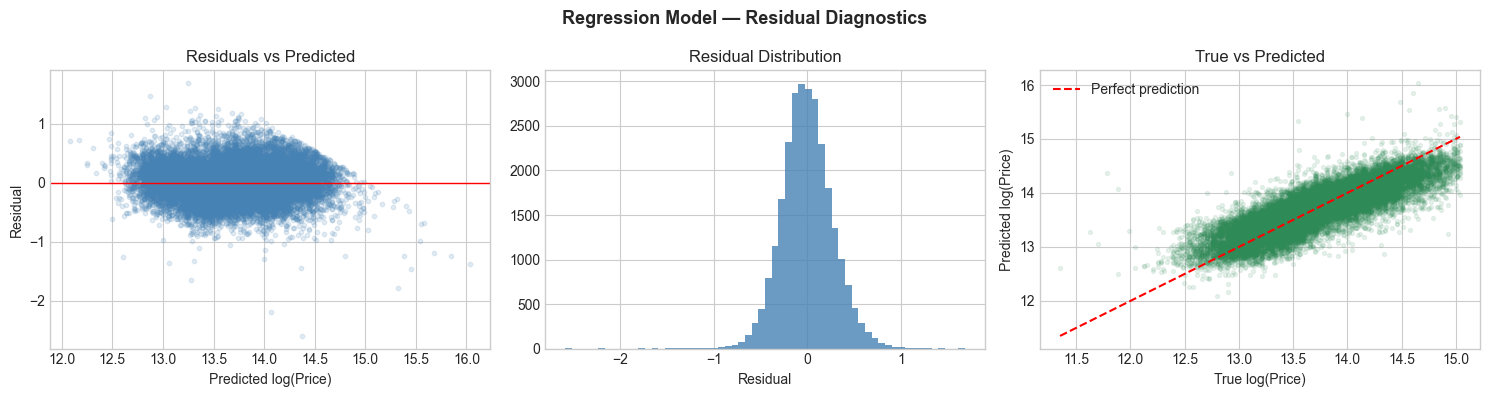

In [33]:
y_pred_all_log = loaded_reg.predict(X)
residuals      = y_reg - y_pred_all_log

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Residuals vs Predicted
axes[0].scatter(y_pred_all_log, residuals, alpha=0.15, s=10, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Predicted log(Price)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

# 2. Residual Distribution
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

# 3. True vs Predicted
axes[2].scatter(y_reg, y_pred_all_log, alpha=0.1, s=8, color='seagreen')
mn, mx = y_reg.min(), y_reg.max()
axes[2].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[2].set_xlabel('True log(Price)')
axes[2].set_ylabel('Predicted log(Price)')
axes[2].set_title('True vs Predicted')
axes[2].legend()

plt.suptitle('Regression Model — Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# WHY residual plots?  They reveal:
# - Heteroscedasticity: variance grows with prediction → log transform needed
# - Non-linearity: curved pattern → polynomial/interaction features needed
# - Outliers: extreme residuals → data quality issue

## Part 14 — Final Results Summary

In [34]:
print("\n" + "="*60)
print("  FINAL ML SYSTEM — PERFORMANCE SUMMARY")
print("="*60)

print("\n  REGRESSION (Predicting log house price)")
print(f"  {'Model':<25} {'MAE':>12} {'RMSE':>12} {'R²':>12}")
print(f"  {'-'*60}")
for r in [lr_results, ridge_results]:
    mae  = np.mean(r['_mae'])
    rmse = np.mean(r['_rmse'])
    r2   = np.mean(r['_r2'])
    print(f"  {r['Model']:<25} {mae:>12.4f} {rmse:>12.4f} {r2:>12.4f}")

print("\n  CLASSIFICATION (Above/below median price)")
print(f"  {'Model':<25} {'Accuracy':>12} {'F1':>12} {'AUC-ROC':>12}")
print(f"  {'-'*60}")
r = log_results
print(f"  {r['Model']:<25} {np.mean(r['_acc']):>12.4f} {np.mean(r['_f1']):>12.4f} {np.mean(r['_auc']):>12.4f}")

print("\n  SAVED MODELS")
print(f"  Regression pipeline    → {reg_path}")
print(f"  Classification pipeline → {clf_path}")
print("="*60)
print("  All metrics computed with 5-Fold Cross-Validation")
print("  Reported as: mean ± std")
print("="*60)


  FINAL ML SYSTEM — PERFORMANCE SUMMARY

  REGRESSION (Predicting log house price)
  Model                              MAE         RMSE           R²
  ------------------------------------------------------------
  Linear Regression               0.2120       0.2757       0.6895
  Ridge (α=1.0)                   0.2120       0.2757       0.6895

  CLASSIFICATION (Above/below median price)
  Model                         Accuracy           F1      AUC-ROC
  ------------------------------------------------------------
  Logistic Regression             0.8556       0.8548       0.9271

  SAVED MODELS
  Regression pipeline    → ./saved_models/regression_pipeline.pkl
  Classification pipeline → ./saved_models/classification_pipeline.pkl
  All metrics computed with 5-Fold Cross-Validation
  Reported as: mean ± std


## BONUS — Streamlit App

Save the code cell below as `app.py` (in the `linear-and-logistic-regression/` folder) and run with:

```bash
streamlit run app.py
```

**How it works**
1. `feature_cols.json` (saved in Part 11) records the exact column order used during training.
2. The app replicates every feature-engineering step from Part 4.
3. `pd.get_dummies` is run on the single-row input, then columns are aligned to `feature_cols` — missing dummy columns are filled with 0, extra ones are dropped.
4. The assembled vector is passed to the loaded pipeline (scaler → model) for prediction.


In [35]:
# app.py — Melbourne Housing Price Predictor
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import json
import os

MODEL_DIR = 'saved_models'

@st.cache_resource
def load_models():
    reg_model    = joblib.load(os.path.join(MODEL_DIR, 'regression_pipeline.pkl'))
    clf_model    = joblib.load(os.path.join(MODEL_DIR, 'classification_pipeline.pkl'))
    with open(os.path.join(MODEL_DIR, 'feature_cols.json')) as f:
        feature_cols = json.load(f)
    return reg_model, clf_model, feature_cols

reg_model, clf_model, feature_cols = load_models()

st.title('Melbourne Housing Price Predictor')
st.markdown('Built with scikit-learn + Streamlit')

col1, col2 = st.columns(2)
with col1:
    rooms      = st.slider('Rooms', 1, 10, 3)
    bedroom2   = st.slider('Bedrooms', 1, 10, 3)
    bathroom   = st.slider('Bathrooms', 1, 5, 1)
    distance   = st.slider('Distance from CBD (km)', 0.0, 50.0, 10.0)
with col2:
    car        = st.slider('Car spaces', 0, 5, 1)
    land_size  = st.number_input('Land size (m²)', 0, 10000, 500)
    bld_area   = st.number_input('Building area (m²)', 0, 1000, 120)
    year_built = st.slider('Year built', 1850, 2023, 1990)

prop_type  = st.selectbox('Property type', ['h', 'u', 't'])
method     = st.selectbox('Sale method', ['S', 'SP', 'PI', 'VB', 'SA'])
regionname = st.selectbox('Region', [
    'Southern Metropolitan', 'Northern Metropolitan',
    'Western Metropolitan', 'Eastern Metropolitan',
    'South-Eastern Metropolitan', 'Eastern Victoria',
    'Northern Victoria', 'Western Victoria',
])

if st.button('Predict Price'):
    # ── Replicate training feature engineering ────────────────────────
    raw = pd.DataFrame([{
        'Rooms': rooms, 'Distance': distance, 'Bedroom2': bedroom2,
        'Bathroom': bathroom, 'Car': car, 'Landsize': land_size,
        'BuildingArea': bld_area, 'YearBuilt': year_built,
        'Type': prop_type, 'Method': method, 'Regionname': regionname,
    }])

    raw['Rooms_per_Bath']   = raw['Rooms'] / (raw['Bathroom'] + 1)
    raw['Property_Age']     = 2023 - raw['YearBuilt']
    raw['Log_Landsize']     = np.log1p(raw['Landsize'])
    raw['Log_BuildingArea'] = np.log1p(raw['BuildingArea'])
    raw['Is_House']         = (raw['Type'] == 'h').astype(int)

    # One-hot encode exactly as during training (drop_first handled by column alignment)
    raw = pd.get_dummies(raw, columns=['Type', 'Method', 'Regionname'])

    # Align to training schema: add missing dummy columns as 0, drop unseen ones
    for col in feature_cols:
        if col not in raw.columns:
            raw[col] = 0
    raw = raw[feature_cols]

    X_new = raw.values.astype(np.float32)

    # ── Predictions ───────────────────────────────────────────────────
    price_log  = reg_model.predict(X_new)[0]
    price_aud  = np.expm1(price_log)
    prob_above = clf_model.predict_proba(X_new)[0, 1]

    st.success(f'### Estimated Price: ${price_aud:,.0f} AUD')
    st.info(f'Probability of being above median price: {prob_above:.1%}')


2026-03-25 21:28:00.283 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 21:28:00.284 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 21:28:00.284 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 21:28:00.313 
  command:

    streamlit run /Users/hnai/Desktop/week-05-ml-masterclass/.venv/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-03-25 21:28:00.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-25 21:28:00.314 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-

## Summary — What You Built

| Stage | What you did |
|---|---|
| Data loading | Loaded Melbourne Housing dataset with 20+ columns |
| Cleaning | Imputed missing values, removed outliers, log-transformed target |
| Feature engineering | Interactions, log transforms, age, binary flags, one-hot encoding |
| Model training | Linear Regression, Ridge, Logistic Regression |
| Validation | KFold (regression) + StratifiedKFold (classification) |
| Metrics | MAE, RMSE, R², Accuracy, F1, AUC-ROC — all with mean ± std |
| Persistence | Saved Pipelines with joblib, loaded for inference |
| Diagnostics | Residual plots to identify model weaknesses |
| BONUS | Streamlit scaffold for live predictions |

---

## Congratulations!

You have completed all **14 activities** of the ML Masterclass.  
You now know how to:
- Preprocess and engineer features professionally
- Implement linear and logistic regression **from scratch**, in sklearn, TensorFlow, and PyTorch
- Apply regularisation (Ridge, Lasso) and early stopping to prevent overfitting
- Validate models scientifically with K-Fold cross-validation
- Compute and interpret all core evaluation metrics
- Build, save, and deploy a complete ML pipeline

**You think like an AI Engineer.**